In [1]:
!pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Gokul\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe())

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000

In [4]:
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


In [5]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Pass Students Avg:\n", pass_avg)
print("\nFail Students Avg:\n", fail_avg)

Pass Students Avg:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Fail Students Avg:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [6]:
df['avg_total'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_total'].idxmax()]

print(top_student[['name', 'avg_total']])

name         Diana
avg_total     94.0
Name: 3, dtype: object


In [7]:
import matplotlib.pyplot as plt

df['avg_score'] = df[subject_cols].mean(axis=1)

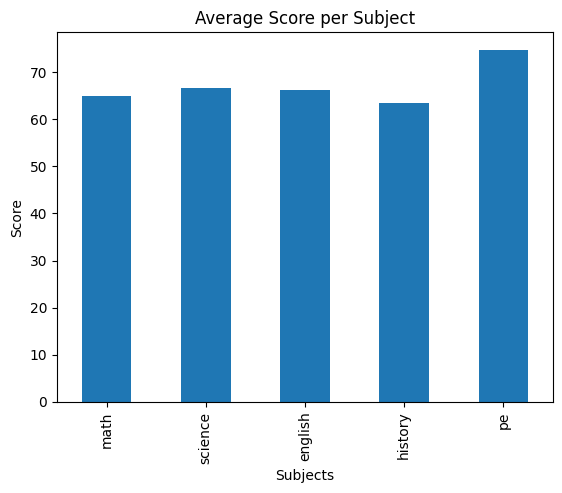

In [8]:
avg_subject = df[subject_cols].mean()

avg_subject.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

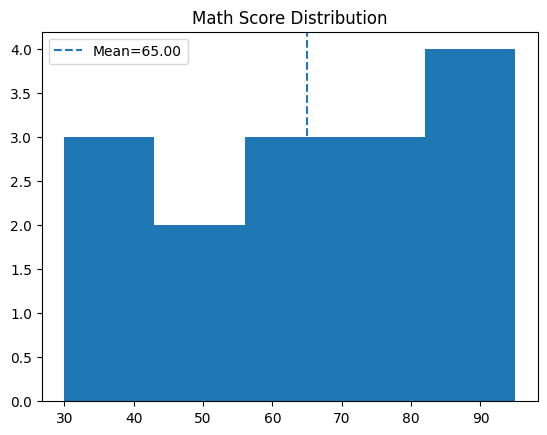

In [9]:
plt.hist(df['math'], bins=5)

mean_val = df['math'].mean()
plt.axvline(mean_val, linestyle='dashed', label=f"Mean={mean_val:.2f}")

plt.title("Math Score Distribution")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

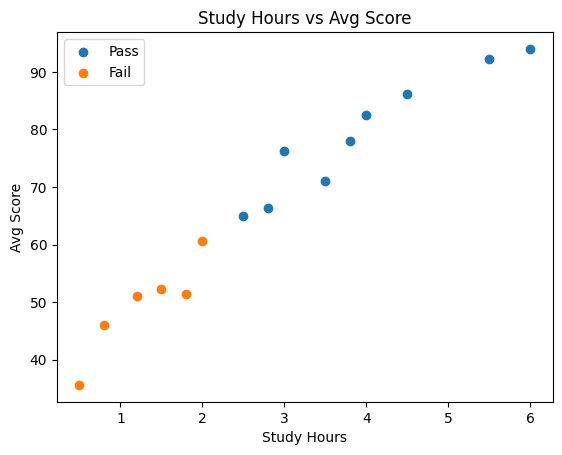

In [10]:
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.xlabel("Study Hours")
plt.ylabel("Avg Score")
plt.title("Study Hours vs Avg Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\Gokul\AppData\Local\Temp\ipykernel_19568\4189426730.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])


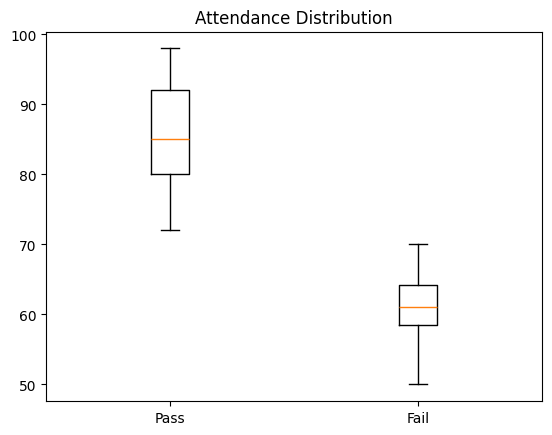

In [11]:
pass_att = pass_df['attendance_pct']
fail_att = fail_df['attendance_pct']

plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])
plt.title("Attendance Distribution")
plt.savefig("plot4_box.png")
plt.show()

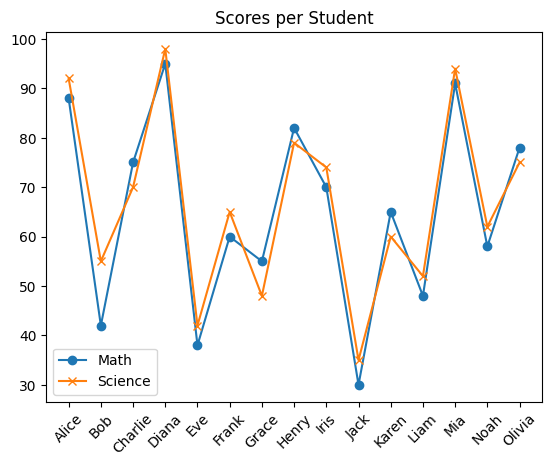

In [12]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()
plt.title("Scores per Student")
plt.savefig("plot5_line.png")
plt.show()

In [13]:
import seaborn as sns

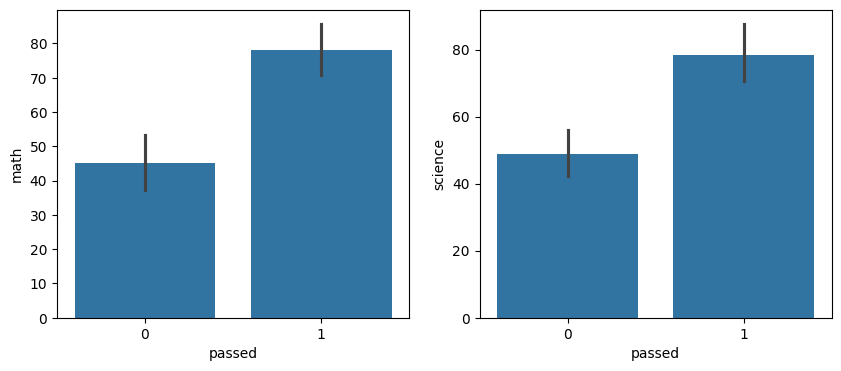

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')

plt.savefig("sns_bar.png")
plt.show()

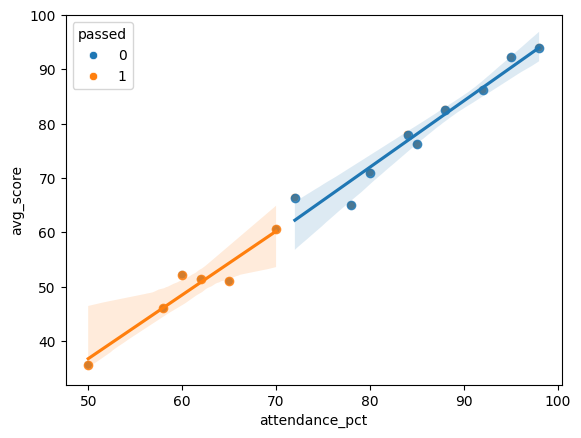

In [15]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=pass_df, x='attendance_pct', y='avg_score')
sns.regplot(data=fail_df, x='attendance_pct', y='avg_score')

plt.savefig("sns_scatter.png")
plt.show()

# Seaborn is easier for statistical plots and requires less code.
# Matplotlib provides more control but needs more manual customization.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']

X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy:", model.score(X_train_scaled, y_train))

Training Accuracy: 1.0


In [18]:
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", model.score(X_test_scaled, y_test))

for i, pred in enumerate(y_pred):
    name = df.loc[X_test.index[i], 'name']
    actual = y_test.iloc[i]
    print(name, actual, pred, "✅" if actual==pred else "❌")

Test Accuracy: 1.0
Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅


In [19]:
import numpy as np

coeff = model.coef_[0]

importance = sorted(zip(features, coeff), key=lambda x: abs(x[1]), reverse=True)

for f, c in importance:
    print(f, c)

english 0.8125127982724648
attendance_pct 0.521876340433209
study_hours_per_day 0.4844326627100155
pe 0.47497406284967797
math 0.43794393086873595
science 0.3230097624690249
history 0.26292892629062437


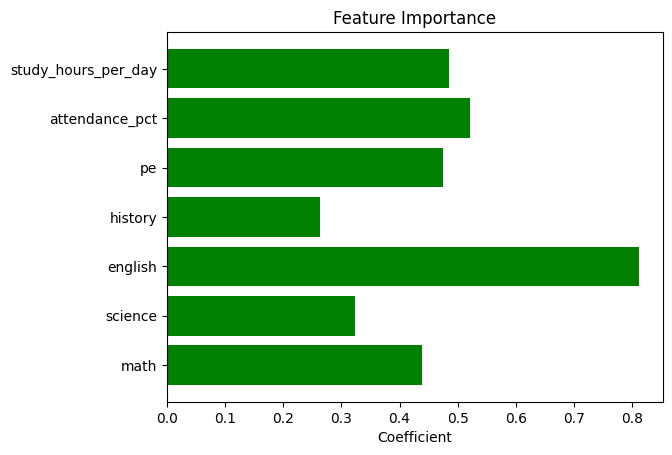

In [20]:
colors = ['green' if c>0 else 'red' for c in coeff]

plt.barh(features, coeff, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.savefig("feature_importance.png")
plt.show()

In [21]:
new_student = [[75,70,68,65,80,82,3.2]]

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


c:\Users\Gokul\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
